In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm  # For DenseNet-264
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Data transforms (DenseNet-264 uses 224x224 input)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (update path)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # Folder with class subfolders
full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)

# Split train/val (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform
val_dataset.dataset.transform = val_transform

# Loaders (batch 32; fits 6GB VRAM, ~3-4GB usage; reduce if OOM)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Classes
class_names = full_dataset.classes
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train: 2088, Val: 523


In [4]:
# Load DenseNet model from timm
# Using 'densenet121' which is a valid model name in timm
# You can also try other valid densenet variants like 'densenet169', 'densenet201'
model = timm.create_model('densenet121', pretrained=True, num_classes=5)

# Freeze all layers except classifier (transfer learning)
model.requires_grad_(False)
model.classifier.requires_grad_(True)  # Unfreeze the final Linear layer

# To GPU
model = model.to(device)

# Summary (optional)
print(model)

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
  

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Optimizer for classifier only first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/200 - Train Loss: 0.1692, Acc: 0.9574 | Val Loss: 0.3344, Acc: 0.8834
Epoch 2/200 - Train Loss: 0.1515, Acc: 0.9598 | Val Loss: 0.3350, Acc: 0.8853
Epoch 3/200 - Train Loss: 0.1542, Acc: 0.9559 | Val Loss: 0.3337, Acc: 0.8795
Epoch 4/200 - Train Loss: 0.1527, Acc: 0.9588 | Val Loss: 0.3474, Acc: 0.8795
Epoch 5/200 - Train Loss: 0.1661, Acc: 0.9526 | Val Loss: 0.3330, Acc: 0.8853
Epoch 6/200 - Train Loss: 0.1573, Acc: 0.9588 | Val Loss: 0.3346, Acc: 0.8872
Epoch 7/200 - Train Loss: 0.1536, Acc: 0.9579 | Val Loss: 0.3320, Acc: 0.8853
Epoch 8/200 - Train Loss: 0.1568, Acc: 0.9579 | Val Loss: 0.3397, Acc: 0.8834
Epoch 9/200 - Train Loss: 0.1667, Acc: 0.9569 | Val Loss: 0.3303, Acc: 0.8910
Epoch 10/200 - Train Loss: 0.1555, Acc: 0.9598 | Val Loss: 0.3343, Acc: 0.8891
Epoch 11/200 - Train Loss: 0.1572, Acc: 0.9598 | Val Loss: 0.3295, Acc: 0.8910
Epoch 12/200 - Train Loss: 0.1665, Acc: 0.9574 | Val Loss: 0.3340, Acc: 0.8948
Epoch 13/200 - Train Loss: 0.1629, Acc: 0.9550 | Val Loss: 0.

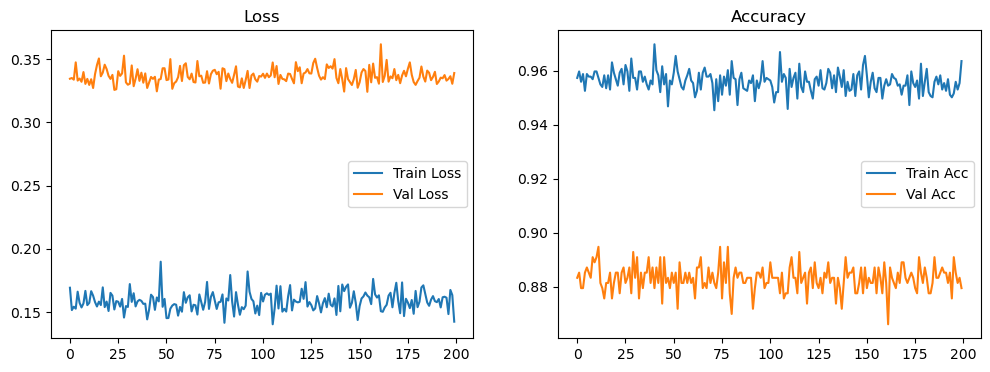

In [8]:
num_epochs = 200
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [9]:
# Eval
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
DenseNet = os.path.join(model_path, 'DenseNet_264')
os.makedirs(DenseNet, exist_ok=True) 
# Save
torch.save(model.state_dict(), os.path.join(DenseNet, 'densenet264_1_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.86      0.80      0.83       120
      Cowpox       0.97      0.92      0.95        93
     Measles       0.93      0.94      0.94        90
   MonkeyPox       0.78      0.83      0.80       110
      Normal       0.89      0.93      0.91       110

    accuracy                           0.88       523
   macro avg       0.89      0.88      0.88       523
weighted avg       0.88      0.88      0.88       523

Accuracy: 0.8795
